<h1><center><big>Semi-supervised learning : le pseudo-labeling</big> <br></center></h1>

<h3><center>Expérimentations sur CIFAR10</center></h3>
<hr>

Nous avons adapté le tutoriel pytorch pour faire du semi-supervisé :

https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

Nous utiliserons CIFAR10, un jeu de données de petites images couleur de 32x32 pixels avec 10 classes différentes.

L'ensemble d'entraînement compte normalement 50 000 images et l'ensemble de test 10 000 images.

Ce jeu de données est entièrement annoté, nous allons donc supprimer artificiellement certaines étiquettes.

In [1]:
#! nvidia-smi

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
#import torch.backends.cudnn as cudnn
import torch.backends.mps as mps

import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm_notebook

Pour la reproductibilité :

In [28]:
SEED=2023
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
mps.benchmark = True #type: ignore
np.random.seed(SEED)
# random.seed(SEED)

In [29]:
device = torch.device('mps:0' if torch.mps.is_available() else 'cpu')
# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

mps:0


In [ ]:
import gc

def free_memory(net):
    del net   # supprimer les références Python importantes
    gc.collect()
    torch.mps.empty_cache()

In [31]:
rep_path= "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_2/"

#### `Chargement de CIFAR10`

In [32]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 32
classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')
trainset = torchvision.datasets.CIFAR10(root=rep_path+'data', train=True,download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,shuffle=True, num_workers=0)
testset = torchvision.datasets.CIFAR10(root=rep_path+'data', train=False,download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,shuffle=False, num_workers=0)


In [ ]:
def imshow(images, labels, predicted_labels=None):
    # Using torchvision to make a grid of the images
    img = torchvision.utils.make_grid(images)

    img = img / 2 + 0.5     # unnormalize
    img = img.permute(1, 2, 0)

    # Plotting the grid
    fig, ax = plt.subplots(figsize=(6, 24))
    plt.imshow(img)

    if predicted_labels is not None:
        # labels prédits si elles existent
        ax.set_xlabel('Predicted labels', fontsize=14, labelpad=12)
        ax.set_xticks(torch.arange(len(images)) * 18 + 10)
        ax.set_xticklabels([classes[predicted_labels[j]]for j in range(len(images))], fontsize=14)

    # labels ground truth
    gax = ax.secondary_xaxis('top')
    gax.set_xlabel('Ground truth', fontsize=14, labelpad=12)
    gax.set_xticks(torch.arange(len(images)) * 18 + 10)
    gax.set_xticklabels([classes[labels[j]]for j in range(len(images))], fontsize=14)
    plt.show()

In [9]:
# Images random du train
dataiter = iter(trainloader)
images, labels = next(dataiter)

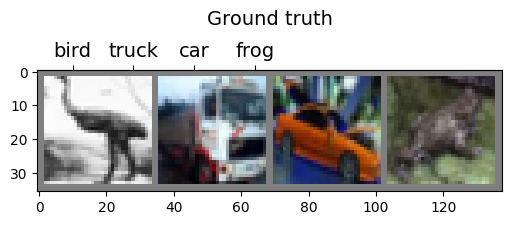

In [10]:
imshow(images[:4], labels[:4])

### `Split artificiel du train`

Divisons l'ensemble des données de train en :


* exemples avec label
* exemples sans label

Comme les données sont entièrement étiquetées, nous supprimons artificiellement certaines étiquettes et leur attribuons la valeur -1.



__`1. Préparation des données`__
 - Séparer un petit jeu de données étiquetées L et un grand jeu non étiqueté U.
 - Nettoyer, normaliser, faire du split train/val/test sur la partie étiquetée comme en supervisé classique

In [11]:
# Nous ne gardons que 40% de l'ensemble des données étiquetées du train
# Vous pourrez essayer une autre valeur par la suite
# A priori que se passe-t-il si cette valeur est très faible ? Très élevée ?
# proportion_labeled_elements = 0.4

def dataset_labelunlabel(trainset, proportion_labeled_elements):
    # on shuffle les indices :
    indices = torch.randperm(len(trainset))

    n_labeled_indices = int(len(indices) * proportion_labeled_elements)
    indices_labeled = sorted(indices[:n_labeled_indices])
    indices_unlabeled = sorted(indices[n_labeled_indices:])

    for index in indices_unlabeled:
        trainset.targets[index] = -1  # on met à -1 le label (valeur arbitraire, on la remplacera pour un label prédit par la suite)

    dataset_train_labeled = torch.utils.data.Subset(trainset, indices_labeled) #type: ignore
    dataset_train_unlabeled = torch.utils.data.Subset(trainset, indices_unlabeled) #type: ignore
    print(f'len dataset_train_labeled {len(dataset_train_labeled)}, len dataset_train_unlabeled : {len(dataset_train_unlabeled)}')
    
    train_loader_labeled = torch.utils.data.DataLoader(dataset_train_labeled, batch_size=batch_size, shuffle=True)
    # Pas de shuffle sur la data loader des unlabeled, sinon on ne pourra pas les remplacer facilement par des labels prédits
    train_loader_unlabeled = torch.utils.data.DataLoader(dataset_train_unlabeled, batch_size=batch_size)
    return train_loader_labeled, train_loader_unlabeled

In [ ]:
def subsetLoaderLabel_pred(loader, model,threshold:float=0):
    """
    Retourne les prédictions sur un subset donné par loader
    """
    with torch.no_grad():
        model.eval()
        all_labels = []
        n_correct=0
        n_total=0
        for i, data in tqdm_notebook(enumerate(loader), total=len(loader)):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)           
            # forward + backward + optimize
            outputs = model(inputs)

            predicted = torch.argmax(outputs, dim=1)
            probs = torch.softmax(outputs, dim=1)

            if threshold != 0 : 
                probs_pred = probs[torch.arange(len(predicted)), predicted]  # (B,)
                mask = probs_pred >= threshold
                selected = predicted[mask]                # (nb_au-dessus_du_seuil,)
                all_labels.extend(selected.cpu().tolist())
            else:
                all_labels.extend(predicted.cpu().tolist())
                print(f'le nombre de classes {len(all_labels)}')
        return all_labels

In [13]:
def train_loaderization(net, batch_size, trainset,train_loader_unlabeled,threshold): 
    labels = subsetLoaderLabel_pred(train_loader_unlabeled, net,threshold)
    for k, index in enumerate(labels):
        trainset.targets[index] = labels[k]
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)    
    return train_loader  

### `Définition d'un petit CNN`

Vous pourrez par la suite essayer un modèle standard, comme un ResNet, pré-entraîné sur ImageNet ou non.

Voir si le pseudo-labeling que l'on fait ici avec un tout petit modèle marche aussi avec un plus gros modèle comme ResNet.


In [14]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [15]:
def train(testloader, trainloader, model, opt, crit, n_epoch=2, loss_every=500):
    """
    Entraînement d'un modèle et plot des courbes de loss et accuracy
    """
    model.train()
    losses = []
    acc = []
    for epoch in range(n_epoch):  # loop over the dataset multiple times
        #print(f"Epoch {epoch}.")

        running_loss = []
        running_acc = []
        #print("Train.")
        #for i, data in tqdm_notebook(enumerate(trainloader), total=len(trainloader)):
        for i, data in enumerate(trainloader):
            inputs, labels = data
            #print(f"inputs shape: {inputs.shape}, labels shape: {labels}")
            inputs = inputs.to(device) 
            labels = labels.to(device)

            # Mettre à zero les gradients des poids du modèle
            opt.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            #print(f"outputs shape: {outputs.shape}, labels shape: {labels.shape}") 
            loss = crit(outputs, labels)
            loss.backward()
            opt.step()

            predicted = torch.argmax(outputs, dim=1)
            running_loss.append(loss.item())
            running_acc.append((predicted == labels).sum().item() / labels.size(0))

            # calculer une moyenne
            if i % loss_every:
                losses.append(np.mean(running_loss))
                acc.append(np.mean(running_acc))

                running_loss = []
                running_acc = []

        test_acc = accuracy(testloader, model)
        print(f"Train Epoch {epoch} Test accuracy: {test_acc:.3f}")

    fig, axes = plt.subplots(1, 2)
    axes[0].plot(losses)
    axes[1].plot(acc)

    axes[0].set_ylabel("Train loss")
    axes[1].set_ylabel("Train acc")
    plt.show()
    print('Apprentissage terminé')


def accuracy(loader, model):
    """
    Args:
        loader: data loader sur lequel on veut calculer une accuracy
        model
    Returns:
        Accuracy
    """
    with torch.no_grad():
        model.eval()  # remove potential dropout, ...
        n_correct = 0
        n_total = 0
 #       for i, data in tqdm_notebook(enumerate(loader), total=len(loader)):
        for i, data in enumerate(loader):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # forward + backward + optimize
            outputs = model(inputs)
            predicted = torch.argmax(outputs, dim=1)
            n_correct += (predicted == labels).sum()
            n_total += labels.size(0)
        return n_correct / n_total


def validate(loader, model):
    """
    Plot des predictions faites avec model, affiche l'accuracy
    """
    dataiter = iter(loader)
    # Get one batch of data
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

    accuracy_model = accuracy(loader, model)
    # print images
    print(f'Accuracy: {accuracy_model:.3f}')
    imshow(images[:4].detach().cpu(), labels[:4], predicted_labels=predictions[:4])

### `Train supervisé avec labels 40 % des labels`

__`2. Entraînement supervisé initial`__
 - Entraîner un modèle de base uniquement sur L (apprentissage supervisé standard).
 - Vérifier ses performances sur un jeu de validation pour disposer d’un point de départ fiable.

len dataset_train_labeled 20000, len dataset_train_unlabeled : 30000
Train Epoch 0 Test accuracy: 0.438
Train Epoch 1 Test accuracy: 0.502
Train Epoch 2 Test accuracy: 0.525
Train Epoch 3 Test accuracy: 0.552
Train Epoch 4 Test accuracy: 0.546


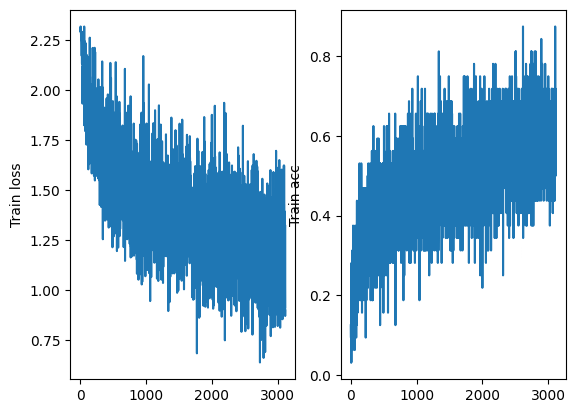

Apprentissage terminé
Accuracy: 0.546


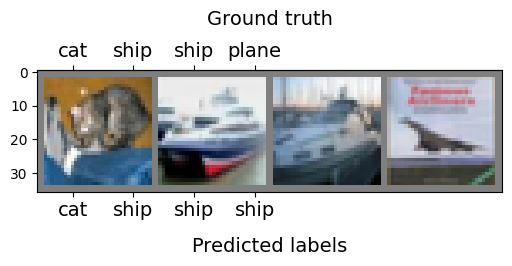

In [16]:
proportion_labeled_elements = 0.4
train_loader_labeled1, train_loader_unlabeled1 = dataset_labelunlabel(trainset, proportion_labeled_elements) 

net1 = Net().to(device)
# tu peux mettre -1 dans ton tenseur de labels pour toutes les positions à “masquer” 
# CrossEntropyLoss(ignore_index=-1) se chargera de ne pas les compter dans la loss ni dans le backprop
criterion = nn.CrossEntropyLoss(ignore_index=-1) # 
optimizer = torch.optim.AdamW(net1.parameters(), lr=1e-3, weight_decay=1e-2)
train(testloader, train_loader_labeled1, net1, optimizer, criterion, n_epoch=5)
validate(testloader, net1)

#### `Utiliser le modèle sur le train unlabeled et utiliser les labels prédits`
__`3. Génération de pseudo-labels`__
 - Appliquer le modèle sur U pour prédire des labels pour les données non étiquetées (pseudo-labels).
 - Ne garder que les prédictions jugées fiables (par exemple probabilité > seuil), afin de limiter le bruit.

In [17]:
new_train_loader_labeled1 = train_loaderization(net1, batch_size, trainset,train_loader_unlabeled1,threshold=0)

  0%|          | 0/938 [00:00<?, ?it/s]

#### `Train du modèle avec la partie labeled + unlabeled avec les "pseudo-labels"`
Remplacer les labels dans trainset par les labels prédits vs"pseudo-labels" pour le dataset unlabeled
__`4. Ré-entraînement avec L ∪ U pseudo-labellé`__
 - Ajouter les exemples de U avec pseudo-labels au jeu d’entraînement et ré-entraîner le modèle.
- Utiliser éventuellement une pondération plus faible pour les pseudo-labels que pour les labels “vrais”

L'accuracy doit être meilleure, le pseudo-labeling aide !

Train Epoch 0 Test accuracy: 0.558
Train Epoch 1 Test accuracy: 0.540
Train Epoch 2 Test accuracy: 0.549
Train Epoch 3 Test accuracy: 0.559
Train Epoch 4 Test accuracy: 0.588


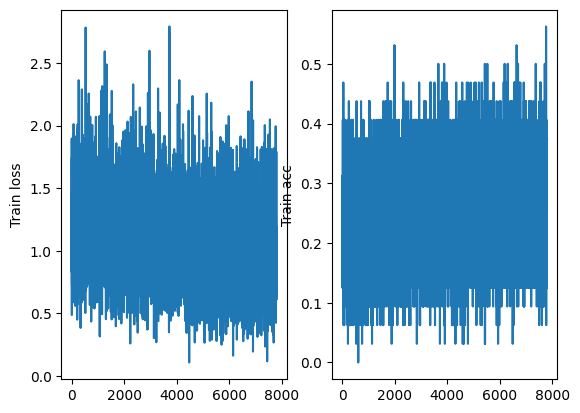

Apprentissage terminé
Accuracy: 0.588


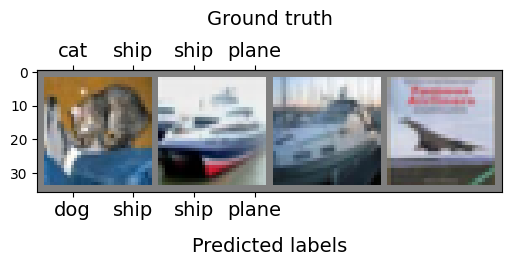

In [18]:
train(testloader, new_train_loader_labeled1, net1, optimizer, criterion, n_epoch=5)
validate(testloader, net1)
free_memory(net1)

#### `Comparaison avec un modèle entraîné sur 100 % du train avec les vraies labels`

len dataset_train_labeled 50000, len dataset_train_unlabeled : 0
Train Epoch 0 Test accuracy: 0.434
Train Epoch 1 Test accuracy: 0.492
Train Epoch 2 Test accuracy: 0.515
Train Epoch 3 Test accuracy: 0.531
Train Epoch 4 Test accuracy: 0.538


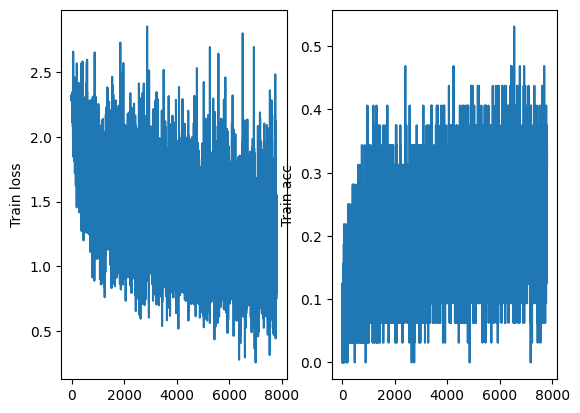

Apprentissage terminé
Accuracy: 0.538


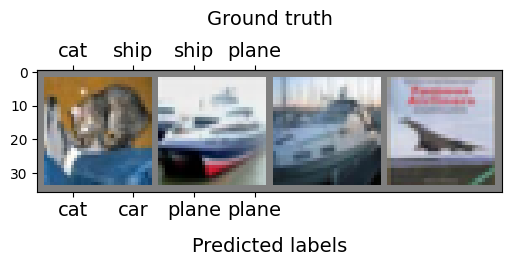

In [20]:
proportion_labeled_elements = 1
train_loader_labeled2, train_loader_unlabeled2 = dataset_labelunlabel(trainset, proportion_labeled_elements) 

net2 = Net().to(device)
optimizer = torch.optim.AdamW(net2.parameters(), lr=1e-3, weight_decay=1e-2)
train(testloader, train_loader_labeled2, net2, optimizer, criterion, n_epoch=5)
validate(testloader, net2)
free_memory(net2)

On obtient environ 10 points de mieux quand même que précedemment !

#### `Faire varier les proportions de données avec et sans labels`

##### `40% labeled only`

len dataset_train_labeled 20000, len dataset_train_unlabeled : 30000
Train Epoch 0 Test accuracy: 0.369
Train Epoch 1 Test accuracy: 0.414
Train Epoch 2 Test accuracy: 0.442
Train Epoch 3 Test accuracy: 0.456
Train Epoch 4 Test accuracy: 0.470


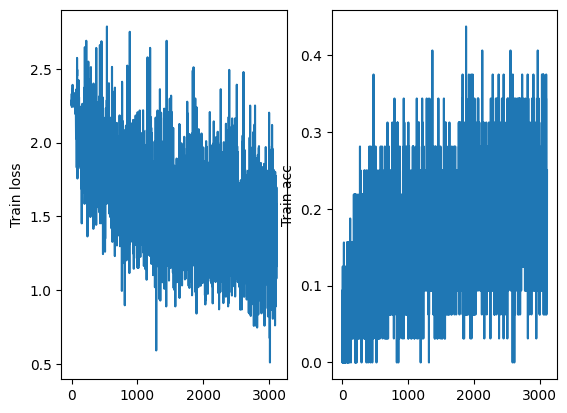

Apprentissage terminé
Accuracy: 0.470


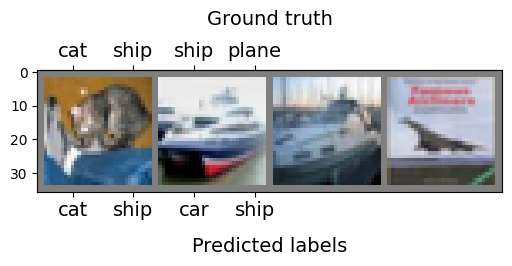

In [21]:
proportion_labeled_elements = 0.4
train_loader_labeled3, train_loader_unlabeled3 = dataset_labelunlabel(trainset, proportion_labeled_elements) 

net3 = Net().to(device)
optimizer = torch.optim.AdamW(net3.parameters(), lr=1e-3, weight_decay=1e-2)
train(testloader, train_loader_labeled3, net3, optimizer, criterion, n_epoch=5)
validate(testloader, net3)

##### `10% labeled only`

len dataset_train_labeled 5000, len dataset_train_unlabeled : 45000
Train Epoch 0 Test accuracy: 0.193
Train Epoch 1 Test accuracy: 0.211
Train Epoch 2 Test accuracy: 0.219
Train Epoch 3 Test accuracy: 0.255
Train Epoch 4 Test accuracy: 0.304


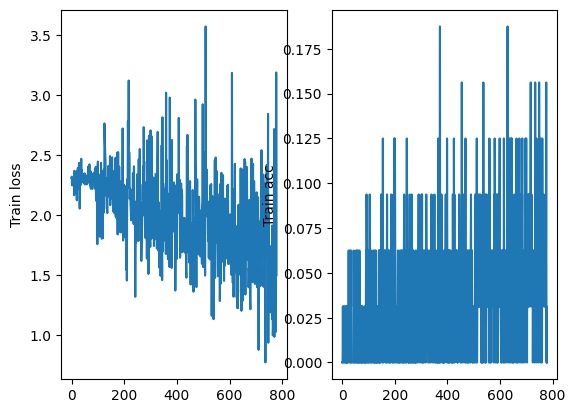

Apprentissage terminé
Accuracy: 0.304


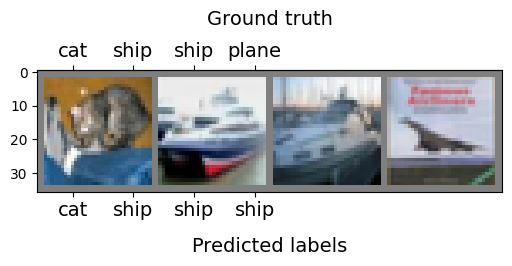

In [23]:
proportion_labeled_elements = 0.1
train_loader_labeled3, train_loader_unlabeled3 = dataset_labelunlabel(trainset, proportion_labeled_elements) 
net3 = Net().to(device)
optimizer = torch.optim.AdamW(net3.parameters(), lr=1e-3, weight_decay=1e-2)
train(testloader, train_loader_labeled3, net3, optimizer, criterion, n_epoch=5)
validate(testloader, net3)

##### `20% labeled and 80% unlabeled`

len dataset_train_labeled 10000, len dataset_train_unlabeled : 40000
Train Epoch 0 Test accuracy: 0.148
Train Epoch 1 Test accuracy: 0.152
Train Epoch 2 Test accuracy: 0.178
Train Epoch 3 Test accuracy: 0.174
Train Epoch 4 Test accuracy: 0.178


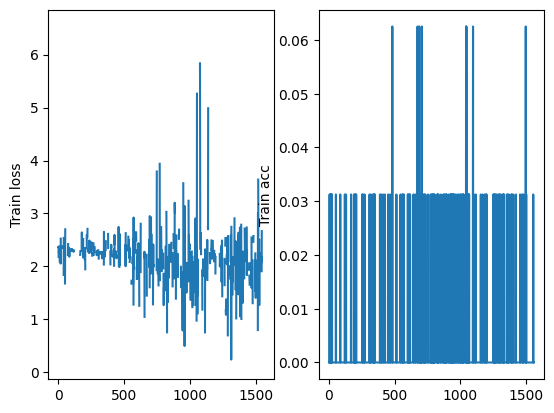

Apprentissage terminé
Accuracy: 0.178


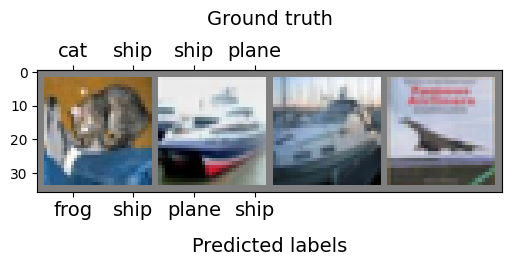

  0%|          | 0/1250 [00:00<?, ?it/s]

Train Epoch 0 Test accuracy: 0.129
Train Epoch 1 Test accuracy: 0.231
Train Epoch 2 Test accuracy: 0.223
Train Epoch 3 Test accuracy: 0.222
Train Epoch 4 Test accuracy: 0.230


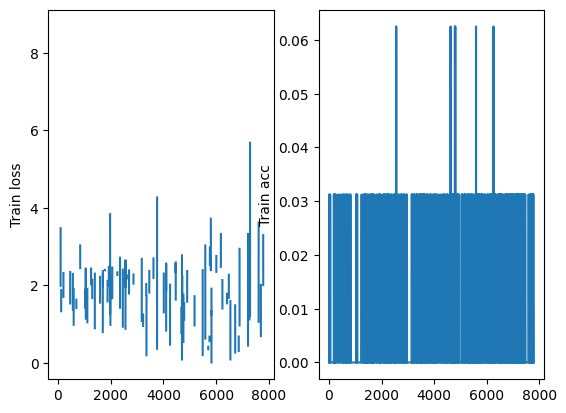

Apprentissage terminé
Accuracy: 0.230


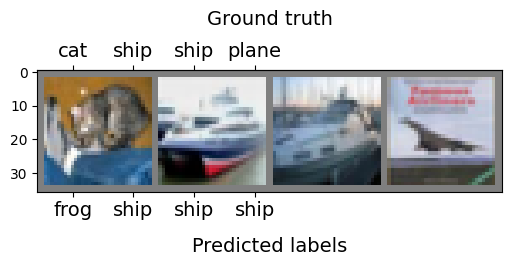

In [24]:
proportion_labeled_elements = 0.2
train_loader_labeled4, train_loader_unlabeled4 = dataset_labelunlabel(trainset, proportion_labeled_elements) 

net4 = Net().to(device)
optimizer = torch.optim.AdamW(net4.parameters(), lr=1e-3, weight_decay=1e-2)
train(testloader, train_loader_labeled4, net4, optimizer, criterion, n_epoch=5)
validate(testloader, net4)

new_train_loader_labeled4 = train_loaderization(net4, batch_size, trainset,train_loader_unlabeled4,threshold=0)
train(testloader, new_train_loader_labeled4, net4, optimizer, criterion, n_epoch=5)
validate(testloader, net4)
free_memory(net4)

#### `40% labeled / 60% unlabeled data and threshold=0.9`

len dataset_train_labeled 20000, len dataset_train_unlabeled : 30000
Train Epoch 0 Test accuracy: 0.380
Train Epoch 1 Test accuracy: 0.401
Train Epoch 2 Test accuracy: 0.443
Train Epoch 3 Test accuracy: 0.450
Train Epoch 4 Test accuracy: 0.484


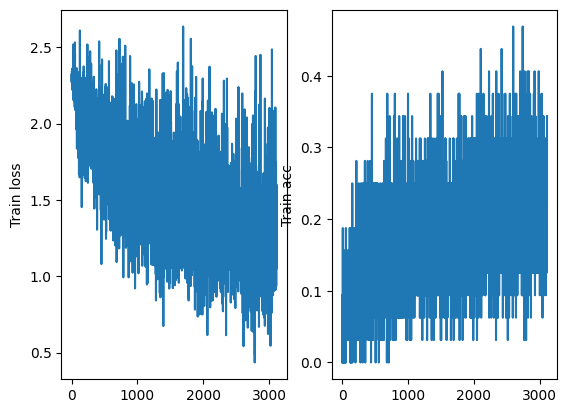

Apprentissage terminé
Accuracy: 0.484


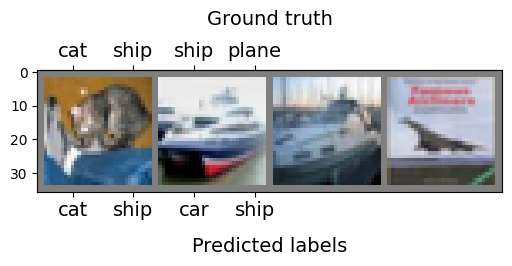

In [34]:
threshold=0.9
proportion_labeled_elements = 0.4
net5 = Net().to(device)
optimizer = torch.optim.AdamW(net5.parameters(), lr=1e-3, weight_decay=1e-2)
train_loader_labeled5, train_loader_unlabeled5 = dataset_labelunlabel(trainset, proportion_labeled_elements) 

train(testloader, train_loader_labeled5, net5, optimizer, criterion, n_epoch=5)
validate(testloader, net5)

  0%|          | 0/938 [00:00<?, ?it/s]

Train Epoch 0 Test accuracy: 0.495
Train Epoch 1 Test accuracy: 0.493
Train Epoch 2 Test accuracy: 0.470
Train Epoch 3 Test accuracy: 0.494
Train Epoch 4 Test accuracy: 0.482


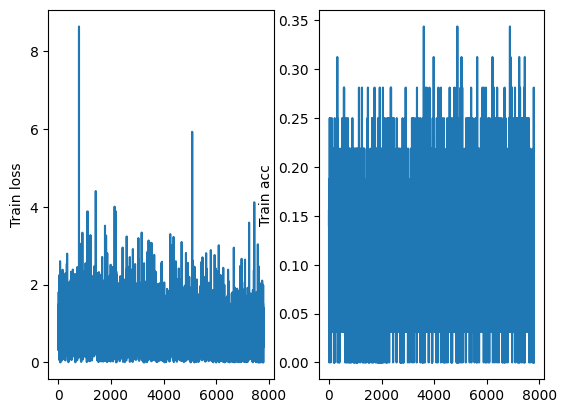

Apprentissage terminé
Accuracy: 0.482


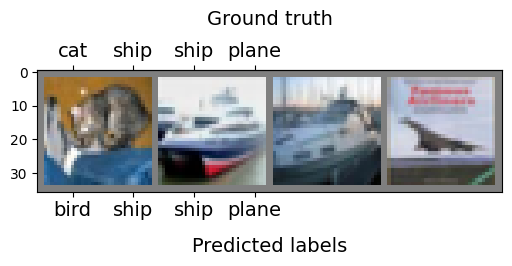

In [52]:
new_train_loader_labeled5 = train_loaderization(net5, batch_size, trainset,train_loader_unlabeled5,threshold)
train(testloader, new_train_loader_labeled5, net5, optimizer, criterion, n_epoch=5)
validate(testloader, net5)
free_memory(net5)

#### __`Tester avec un ResNet pré-entraîné ou non`__
- ResNet‑18 avec des poids pré‑entraînés sur ImageNet‑1K.
- ResNet18_Weights.DEFAULT est défini comme l’énumération qui pointe vers les poids pré‑entraînés par défaut
- équivalent à ResNet18_Weights.IMAGENET1K_V1, 
- le modèle n’est pas initialisé aléatoirement mais avec ces poids appris.

len dataset_train_labeled 20000, len dataset_train_unlabeled : 30000
Train Epoch 0 Test accuracy: 0.218
Train Epoch 1 Test accuracy: 0.259
Train Epoch 2 Test accuracy: 0.271
Train Epoch 3 Test accuracy: 0.284
Train Epoch 4 Test accuracy: 0.349


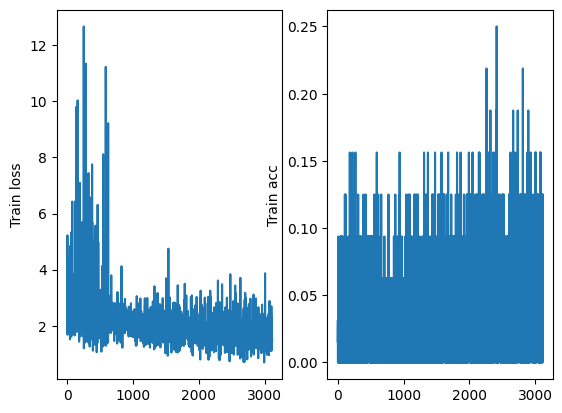

Apprentissage terminé
Accuracy: 0.349


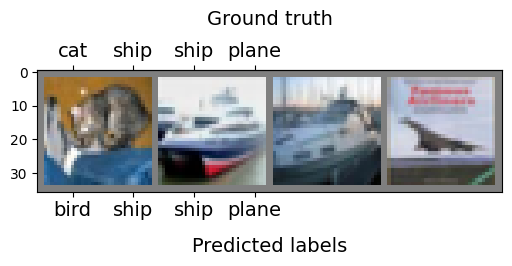

In [55]:
import torch
import torch.nn as nn
from torchvision import models

threshold=0.9
proportion_labeled_elements = 0.4
modelResenet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
# 2) Adapter la dernière couche pour ton nombre de classes
num_classes = len(classes)  # par ex. CIFAR-10
in_features = modelResenet.fc.in_features
modelResenet.fc = nn.Linear(in_features, num_classes).to(device)

optimizer = torch.optim.AdamW(modelResenet.parameters(), lr=1e-3, weight_decay=1e-2)
train_loader_labeled6, train_loader_unlabeled6 = dataset_labelunlabel(trainset, proportion_labeled_elements) 

train(testloader, train_loader_labeled6, modelResenet, optimizer, criterion, n_epoch=5)
validate(testloader, modelResenet)

free_memory(modelResenet)